# 03 · 환경 검증

이 노트북은 학습에 필요한 모든 라이브러리가 본인 PC 에 정상 설치되었는지 점검합니다.

**사용법**: 위에서부터 셀을 *순서대로* 실행하세요. (단축키: `Shift + Enter`)

**모든 셀이 에러 없이 통과** 하면 환경 구성이 끝난 것입니다. 한 셀이라도 빨간 메시지가 뜨면 그 셀의 마지막 줄을 캡처해 두세요.


## 1. Python 버전


In [1]:
import sys
print(f"Python: {sys.version}")
major, minor = sys.version_info[:2]
assert (major, minor) >= (3, 12), "Python 3.12 이상이 필요합니다. SETUP 가이드를 다시 확인해 주세요."
print("Python 버전 OK")


Python: 3.12.3 (main, Apr 15 2024, 18:07:06) [Clang 17.0.6 ]
Python 버전 OK


## 2. 핵심 라이브러리 import


In [2]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"statsmodels {sm.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {sns.__version__}")
print(f"sklearn     {sklearn.__version__}")


numpy       2.4.4
pandas      3.0.2
scipy       1.17.1
statsmodels 0.14.6
matplotlib  3.10.9
seaborn     0.13.2
sklearn     1.8.0


## 3. NumPy 기본 연산

다섯 개 숫자의 평균이 우리가 손으로 계산한 값과 같은지 봅니다.


In [3]:
arr = np.array([1, 2, 3, 4, 5])
assert arr.mean() == 3.0
print(f"평균: {arr.mean()}")


평균: 3.0


## 4. Pandas DataFrame


In [4]:
df = pd.DataFrame({"x": [1, 2, 3], "y": [4, 5, 6]})
assert df["x"].sum() == 6
df


,x,y
0,1,4
1,2,5
2,3,6


## 5. SciPy — 표준정규분포 누적확률

1.96 보다 작을 확률은 약 0.975 입니다 (양측 95% 신뢰구간을 만들 때 자주 쓰는 값).


In [5]:
from scipy import stats
p = stats.norm.cdf(1.96)
assert abs(p - 0.975) < 0.001
print(f"P(Z <= 1.96) ≈ {p:.4f}")


P(Z <= 1.96) ≈ 0.9750


## 6. statsmodels — 1 분 회귀

$y = 2x + 1$ 인 데이터에 단순선형회귀를 적합하면 기울기는 2, 절편은 1 이 나와야 합니다.


In [6]:
x = np.arange(10)
y = 2 * x + 1
X = sm.add_constant(x)  # 절편 항 추가
model = sm.OLS(y, X).fit()
print(model.params)
assert abs(model.params[0] - 1) < 1e-9 and abs(model.params[1] - 2) < 1e-9
print("OLS 적합 OK")


[1. 2.]
OLS 적합 OK


## 7. matplotlib + seaborn 그림


/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51004 (\N{HANGUL SYLLABLE EU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-pack

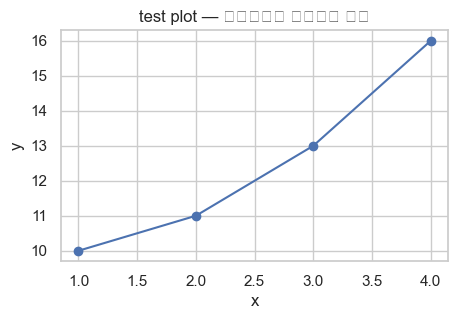

In [7]:
sns.set_theme(context="notebook", style="whitegrid")
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot([1, 2, 3, 4], [10, 11, 13, 16], marker="o")
ax.set_title("test plot — 정상적으로 그려지면 통과")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()


## 8. scikit-learn — 1 줄 회귀


In [8]:
from sklearn.linear_model import LinearRegression
X = np.array([[1], [2], [3], [4]])
y = np.array([2, 4, 6, 8])
reg = LinearRegression().fit(X, y)
print(f"기울기: {reg.coef_[0]}, 절편: {reg.intercept_}")
assert abs(reg.coef_[0] - 2) < 1e-9
print("sklearn OK")


기울기: 2.0, 절편: 0.0
sklearn OK


## ✅ 환경 검증 통과

여기까지 에러 없이 도달했다면 학습을 시작할 준비가 끝났습니다. 다음 두 곳 중 어느 쪽으로 가도 좋습니다.

- 도구 사용에 자신이 없다면 → [`02-tools-tour.ipynb`](02-tools-tour.ipynb) 30 분 투어.
- 바로 통계 학습을 시작하고 싶다면 → [`../01-descriptive-stats/01-when-mean-lies.md`](../01-descriptive-stats/01-when-mean-lies.md).
